# 7. Transformer Encoder

**Цель:** Собрать энкодерный блок трансформера: Multi-Head Self-Attention → Add & Norm → FFN → Add & Norm. Реализовать LayerNorm, FFN, Residual connections и стекирование блоков.

---

## 🎭 Мем дня

*Encoder: «Я тебя услышал». И правда услышал — потому что Self-Attention позволяет видеть весь контекст сразу.*

![Мем про encoder](memes/07_encoder.png)


In [1]:
# Pre-Norm vs Post-Norm: LayerNorm до подслоёв (Pre-Norm) стабилизирует обучение
#   сохраняя масштаб градиентов согласованным между слоями
# LayerNorm vs BatchNorm: LayerNorm нормализует по признакам на токен, а не по батчу
#   — это работает для последовательностей разной длины, где статистики батча нестабильны
# Residual connections: skip-соединения позволяют градиентам течь напрямую через сеть,
#   предотвращая проблему затухания градиентов в глубоких стеках
import sys, os, logging, math

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Вместо logging используем простой print — учебный курс, зачем нам логи?
import builtins as _builtins
def _log(msg, *args):
    if args:
        _builtins.print(msg % args)
    else:
        _builtins.print(msg)

import types
log = types.SimpleNamespace(info=_log, debug=_log, warning=_log, error=_log)



device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)

Используем устройство: mps


## 7.1 Layer Normalization

**Формула:**
$$\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

- Нормализуется по последней размерности (d_model)
- $\mu, \sigma$ — среднее и дисперсия по признакам для каждого токена
- $\gamma$ (scale) и $\beta$ (shift) — обучаемые параметры
- $\epsilon$ — малая константа для численной стабильности

**Почему LayerNorm, а не BatchNorm?**
- BatchNorm зависит от batch_size и плохо работает при переменной длине
- LayerNorm нормализует каждый токен независимо
- В трансформерах LayerNorm стабильнее при обучении

In [2]:
log.debug("Implementing LayerNorm from scratch")

# LayerNorm: нормализует каждый токен независимо по размерности признаков (d_model)
# Почему LayerNorm, а не BatchNorm:
#   BatchNorm вычисляет среднее/дисперсию на признак по батчу — нестабильно для разной длины
#   LayerNorm вычисляет среднее/дисперсию на токен по признакам — работает для любой длины
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))  # learned scale, initialized to 1
        self.beta = nn.Parameter(torch.zeros(d_model))   # learned shift, initialized to 0
        self.eps = eps  # small constant for numerical stability
    
    def forward(self, x):
        mu = x.mean(dim=-1, keepdim=True)           # mean across features per token
        sigma = x.std(dim=-1, keepdim=True, unbiased=False)  # std across features per token
        return self.gamma * (x - mu) / (sigma + self.eps) + self.beta  # scale & shift

# Сравнение со встроенным LayerNorm от PyTorch
x = torch.randn(4, 10, 32)  # (batch, seq_len, d_model)
our_ln = LayerNorm(32)
torch_ln = nn.LayerNorm(32)

with torch.no_grad():
    our_ln.gamma.data = torch_ln.weight.data
    our_ln.beta.data = torch_ln.bias.data
    diff = (our_ln(x) - torch_ln(x)).abs().max().item()
    print(f"Max difference from nn.LayerNorm: {diff:.2e}")
    log.info("LayerNorm implementation matches nn.LayerNorm: diff=%.2e", diff)

Implementing LayerNorm from scratch
Max difference from nn.LayerNorm: 2.77e-05
LayerNorm implementation matches nn.LayerNorm: diff=2.77e-05


## Почему LayerNorm, а не BatchNorm

**Layer Normalization (LayerNorm):**

$$
\mu_t = \frac{1}{d}\sum_{j=1}^{d} x_{tj}, \quad \sigma_t^2 = \frac{1}{d}\sum_{j=1}^{d} (x_{tj} - \mu_t)^2
$$

$$
\text{LayerNorm}(x_t) = \gamma \odot \frac{x_t - \mu_t}{\sqrt{\sigma_t^2 + \epsilon}} + \beta
$$

- Среднее и дисперсия считаются **по признакам** для каждого токена $t$ (по последней оси)
- Каждый токен нормализуется независимо от других
- Работает для последовательностей **любой длины**

**Batch Normalization (BatchNorm):**

$$
\mu_j = \frac{1}{B}\sum_{i=1}^{B} x_{ij}, \quad \sigma_j^2 = \frac{1}{B}\sum_{i=1}^{B} (x_{ij} - \mu_j)^2
$$

- Среднее и дисперсия считаются **по батчу** для каждого признака $j$
- Зависит от размера батча и стабильности статистик
- **Проблема в трансформерах:**
  - Последовательности имеют разную длину (padding)
  - Статистики BatchNorm искажаются из-за разного количества реальных токенов
  - На инференсе с длиной, отличной от тренировочной, статистики невалидны

**Итог:** LayerNorm — естественный выбор для трансформеров, так как нормализация не зависит от длины последовательности и размера батча.

## 7.2 Feed-Forward Network (FFN)

**Структура:** Linear → GELU → Linear
$$
\text{FFN}(x) = W_2 \cdot \text{GELU}(W_1 \cdot x + b_1) + b_2
$$

- Внутренняя размерность: d_ff = 4 * d_model
- GELU предпочтительнее ReLU в трансформерах (гладкая нелинейность)

In [3]:
log.debug("Implementing FeedForward network")

# FFN (полносвязная сеть): двухслойный MLP, применяемый к каждому токену: расширение → сжатие представления
# GELU предпочтительнее ReLU в трансформерах — гладкая, ненулевая для отрицательных значений
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model  # inner dimension is 4x d_model by default
        self.fc1 = nn.Linear(d_model, d_ff)       # expansion: d_model -> 4*d_model
        self.fc2 = nn.Linear(d_ff, d_model)       # contraction: 4*d_model -> d_model
        self.dropout = nn.Dropout(dropout)         # dropout applied after activation
        log.debug("FeedForward: d_model=%d, d_ff=%d", d_model, d_ff)
    
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))  # Linear -> GELU -> Dropout -> Linear

ffn = FeedForward(d_model=32)
x = torch.randn(4, 10, 32)
print(f"FFN input:  {x.shape}")
print(f"FFN output: {ffn(x).shape}")
log.info("FeedForward forward pass OK")

Implementing FeedForward network
FeedForward: d_model=32, d_ff=128
FFN input:  torch.Size([4, 10, 32])
FFN output: torch.Size([4, 10, 32])
FeedForward forward pass OK


## Residual connections: как решают затухание градиентов

**Проблема:** В глубоких сетях градиенты при обратном распространении перемножаются через цепочку производных, что приводит к их экспоненциальному затуханию.

**Решение:** Остаточная связь (skip connection) позволяет градиенту "обтекать" преобразование:

$$
y = x + F(x)
$$

где $F(x)$ — Attention или FFN (с Pre-Norm).

**Градиент через остаточную связь:**

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \left(1 + \frac{\partial}{\partial x}F(x)\right)
$$

Единичный член ($1$) в скобках — это прямой проход градиента через skip connection. Даже если $\frac{\partial}{\partial x}F(x) \to 0$ (градиент через слой затухает), единица гарантирует, что градиент не исчезнет полностью.

**В контексте Pre-Norm:**
$$
y = x + \text{Sublayer}(\text{LayerNorm}(x))
$$
- Norm применяется до Sublayer, поэтому Sublayer получает нормализованный вход
- Residual connection добавляет оригинальный $x$ к выходу Sublayer
- Градиент течёт через identity-путь ($x$) напрямую, минуя LayerNorm и Sublayer

## 7.3 Residual Connections

**Зачем остаточные связи?**
- Позволяют градиенту "обтекать" слои (shortcut)
- Решают проблему затухания градиента в глубоких сетях
- Теоретически: каждый блок учится "поправке" к входу

**Формула:** output = LayerNorm(x + Sublayer(x))

**Pre-Norm vs Post-Norm:**
1. **Post-Norm** (оригинальный Vaswani): Sublayer → Add → Norm
2. **Pre-Norm** (современный стандарт): Norm → Sublayer → Add
- Pre-Norm стабильнее при обучении (градиенты не затухают в глубоких стеках)

## 7.4 TransformerEncoderBlock

Собираем всё вместе: Self-Attention → Add & Norm → FFN → Add & Norm

In [4]:
log.debug("Implementing TransformerEncoderBlock")

# Scaled dot-product attention: Q @ K^T / sqrt(d_k), softmax, затем взвешенная сумма V
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)  # compute attention scores, scale by 1/sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))  # mask padded positions
    attn = F.softmax(scores, dim=-1)  # softmax over keys
    return attn @ V, attn  # weighted sum and attention weights

# Multi-Head Attention: проекция Q, K, V в n_heads подпространств, параллельное внимание
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0  # d_model must be divisible by n_heads
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # dimension per head
        self.W_Q = nn.Linear(d_model, d_model, bias=False)  # query projection
        self.W_K = nn.Linear(d_model, d_model, bias=False)  # key projection
        self.W_V = nn.Linear(d_model, d_model, bias=False)  # value projection
        self.W_O = nn.Linear(d_model, d_model, bias=False)  # output projection
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, Q, K, V, mask=None):
        batch = Q.size(0)
        # Проекция и изменение формы до (batch, n_heads, seq_len, d_k)
        Q = self.W_Q(Q).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        # Scaled dot-product attention для всех голов
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = self.dropout(F.softmax(scores, dim=-1))  # attention dropout
        
        # Конкатенация голов и проекция
        output = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.d_model)
        return self.W_O(output), attn

# Энкодер block с Pre-Norm: Norm -> Sublayer -> Add (residual)
# В Post-Norm (оригинальный Transformer): Sublayer -> Add -> Norm
# Pre-Norm стабилизирует обучение: градиенты текут через identity-путь, LayerNorm сохраняет масштаб
class TransformerEncoderBlock(nn.Module):
    """Один блок энкодера трансформера (Pre-Norm)."""
    
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads, dropout)  # self-attention sub-layer
        self.ffn = FeedForward(d_model, d_ff, dropout)                  # feed-forward sub-layer
        self.norm1 = nn.LayerNorm(d_model)  # LayerNorm before attention (Pre-Norm)
        self.norm2 = nn.LayerNorm(d_model)  # LayerNorm before FFN (Pre-Norm)
        self.dropout1 = nn.Dropout(dropout)  # dropout after attention output
        self.dropout2 = nn.Dropout(dropout)  # dropout after FFN output
        log.debug("TransformerEncoderBlock: d_model=%d, n_heads=%d, d_ff=%d",
                  d_model, n_heads, d_ff or 4*d_model)
    
    def forward(self, x, mask=None):
        # Pre-Norm: сначала LayerNorm, потом подслой, потом добавление residual
        attn_out, attn_weights = self.attention(self.norm1(x), self.norm1(x), self.norm1(x), mask)  # self-attention with Pre-Norm
        x = x + self.dropout1(attn_out)  # residual connection: input + attention output
        
        ffn_out = self.ffn(self.norm2(x))  # FFN (полносвязная сеть) with Pre-Norm
        x = x + self.dropout2(ffn_out)  # residual connection: (x + attn) + FFN output
        
        return x, attn_weights  # output and attention weights for inspection

block = TransformerEncoderBlock(d_model=32, n_heads=4)
log.info("TransformerEncoderBlock created")

Implementing TransformerEncoderBlock
FeedForward: d_model=32, d_ff=128
TransformerEncoderBlock: d_model=32, n_heads=4, d_ff=128
TransformerEncoderBlock created


In [5]:
log.debug("Testing TransformerEncoderBlock forward pass")

# Проверяем, что encoder block сохраняет форму (residual connection гарантирует это)
batch, seq_len, d_model = 4, 16, 32
x = torch.randn(batch, seq_len, d_model)

output, attn_weights = block(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention:    {attn_weights.shape}")
print(f"Input is output shape match: {x.shape == output.shape}")
print(f"Output differs from input:   {not torch.allclose(x, output, atol=1e-4)}")  # should be True — output != input
log.info("Encoder block forward pass OK")

Testing TransformerEncoderBlock forward pass
Input shape:  torch.Size([4, 16, 32])
Output shape: torch.Size([4, 16, 32])
Attention:    torch.Size([4, 4, 16, 16])
Input is output shape match: True
Output differs from input:   True
Encoder block forward pass OK


## 7.5 Стекирование блоков: TransformerEncoder

Несколько энкодерных блоков, stacked последовательно.

In [6]:
log.debug("Implementing TransformerEncoder with stacked blocks")

# Стек N одинаковых encoder блоков. Pre-Norm + residual соединения делают глубокий стек обучаемым.
# Без residual градиенты затухли бы через 6+ слоёв нелинейных преобразований.
class TransformerEncoder(nn.Module):
    """Стопка TransformerEncoderBlock."""
    
    def __init__(self, num_layers, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([  # stack of encoder blocks
            TransformerEncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        log.debug("TransformerEncoder: %d layers, d_model=%d, n_heads=%d", num_layers, d_model, n_heads)
    
    def forward(self, x, mask=None):
        all_attentions = []  # collect attention weights from every layer
        for i, layer in enumerate(self.layers):
            log.debug("Encoder layer %d forward", i)
            x, attn = layer(x, mask)  # pass through one encoder block
            all_attentions.append(attn)
        return x, all_attentions

encoder = TransformerEncoder(num_layers=6, d_model=64, n_heads=8)
print(f"Encoder layers: {len(encoder.layers)}")
print(f"Total params: {sum(p.numel() for p in encoder.parameters()):,}")
log.info("TransformerEncoder created, total params=%d", sum(p.numel() for p in encoder.parameters()))

Implementing TransformerEncoder with stacked blocks
FeedForward: d_model=64, d_ff=256
TransformerEncoderBlock: d_model=64, n_heads=8, d_ff=256
FeedForward: d_model=64, d_ff=256
TransformerEncoderBlock: d_model=64, n_heads=8, d_ff=256
FeedForward: d_model=64, d_ff=256
TransformerEncoderBlock: d_model=64, n_heads=8, d_ff=256
FeedForward: d_model=64, d_ff=256
TransformerEncoderBlock: d_model=64, n_heads=8, d_ff=256
FeedForward: d_model=64, d_ff=256
TransformerEncoderBlock: d_model=64, n_heads=8, d_ff=256
FeedForward: d_model=64, d_ff=256
TransformerEncoderBlock: d_model=64, n_heads=8, d_ff=256
TransformerEncoder: 6 layers, d_model=64, n_heads=8
Encoder layers: 6
Total params: 298,368
TransformerEncoder created, total params=298368


In [7]:
log.debug("Testing full encoder forward pass")

# Прямой проход через все 6 слоёв; проверяем размерности
batch, seq_len, d_model = 2, 12, 64
x = torch.randn(batch, seq_len, d_model)
output, attentions = encoder(x)

print(f"Encoder input:              {x.shape}")
print(f"Encoder output:             {output.shape}")
print(f"Number of attention maps:   {len(attentions)}")  # should equal num_layers
print(f"Per-layer attention shape:  {attentions[0].shape}")
log.info("Full encoder forward pass OK")

Testing full encoder forward pass
Encoder layer 0 forward
Encoder layer 1 forward
Encoder layer 2 forward
Encoder layer 3 forward
Encoder layer 4 forward
Encoder layer 5 forward
Encoder input:              torch.Size([2, 12, 64])
Encoder output:             torch.Size([2, 12, 64])
Number of attention maps:   6
Per-layer attention shape:  torch.Size([2, 8, 12, 12])
Full encoder forward pass OK


## 7.6 Визуализация: активации после каждого компонента

Посмотрим, как меняются эмбеддинги после каждого блока.

Visualizing activations across encoder layers
FeedForward: d_model=16, d_ff=64
TransformerEncoderBlock: d_model=16, n_heads=2, d_ff=64
FeedForward: d_model=16, d_ff=64
TransformerEncoderBlock: d_model=16, n_heads=2, d_ff=64
FeedForward: d_model=16, d_ff=64
TransformerEncoderBlock: d_model=16, n_heads=2, d_ff=64
FeedForward: d_model=16, d_ff=64
TransformerEncoderBlock: d_model=16, n_heads=2, d_ff=64
TransformerEncoder: 4 layers, d_model=16, n_heads=2


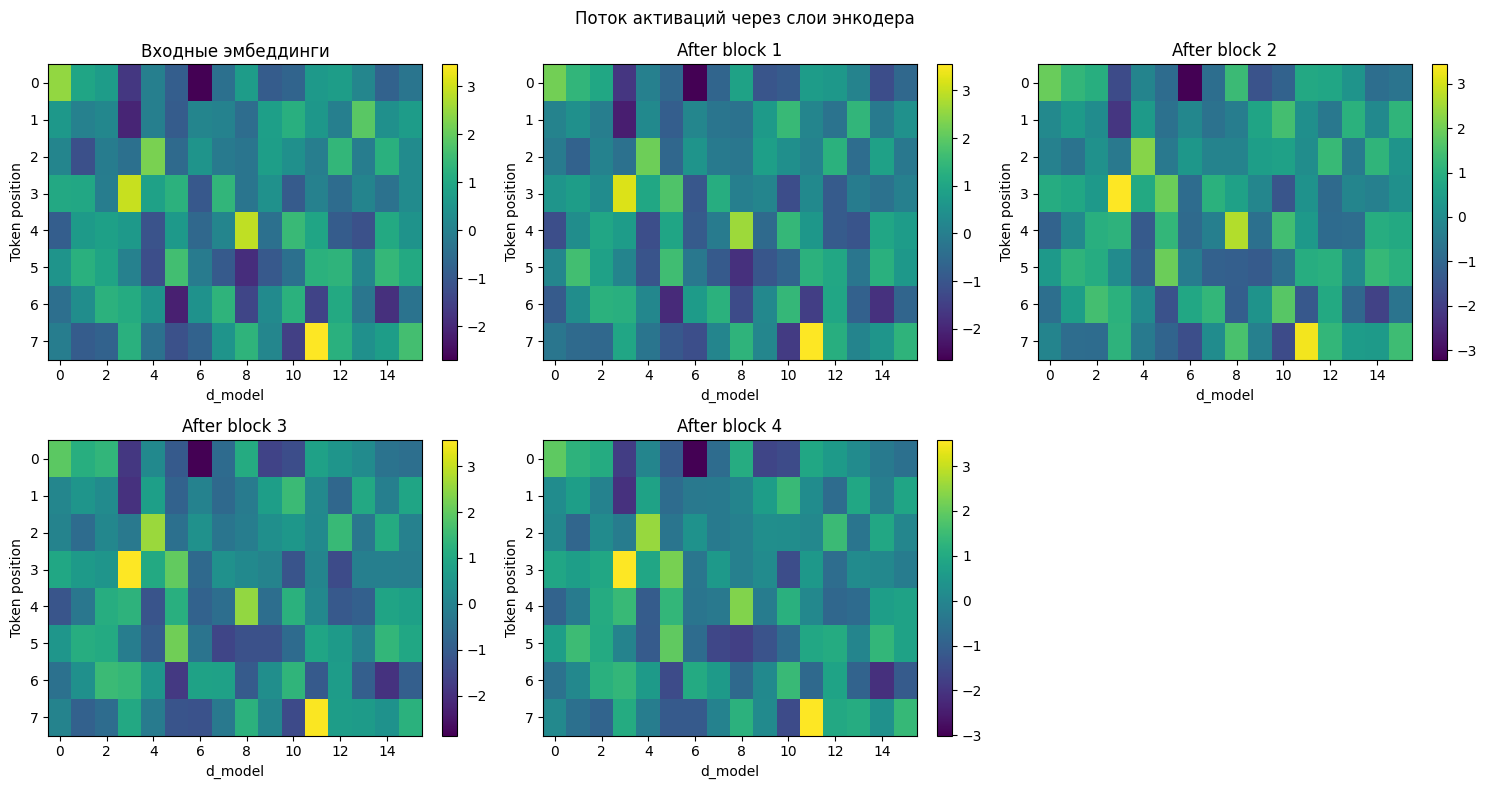

Encoder activations visualized


In [8]:
log.debug("Visualizing activations across encoder layers")

# Создаём маленький энкодер и отслеживаем активации после каждого блока
encoder_small = TransformerEncoder(num_layers=4, d_model=16, n_heads=2, dropout=0.0)
x = torch.randn(1, 8, 16)

layer_outputs = [x]
current = x
for i, layer in enumerate(encoder_small.layers):
    current, attn = layer(current)
    layer_outputs.append(current.detach())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i < len(layer_outputs):
        im = ax.imshow(layer_outputs[i][0].numpy(), cmap='viridis', aspect='auto')
        ax.set_title(f'After block {i}' if i > 0 else 'Входные эмбеддинги')
        ax.set_xlabel('d_model')
        ax.set_ylabel('Token position')
        plt.colorbar(im, ax=ax, fraction=0.046)
axes.flat[-1].axis('off')
plt.suptitle('Поток активаций через слои энкодера')
plt.tight_layout()
plt.show()
log.info("Encoder activations visualized")

In [9]:
# Итог реализации трансформер энкодера
print("=== Transformer Encoder complete ===")
print("Topics covered:")
print("  - Layer Normalization from scratch")
print("  - Feed-Forward Network: Linear -> GELU -> Linear")
print("  - Residual connections (Pre-Norm architecture)")
print("  - Multi-Head Self-Attention in encoder")
print("  - TransformerEncoderBlock with Add & Norm")
print("  - Stacked TransformerEncoder")
print("  - Activation flow visualization through layers")
log.info("Encoder notebook complete")

=== Transformer Encoder complete ===
Topics covered:
  - Layer Normalization from scratch
  - Feed-Forward Network: Linear -> GELU -> Linear
  - Residual connections (Pre-Norm architecture)
  - Multi-Head Self-Attention in encoder
  - TransformerEncoderBlock with Add & Norm
  - Stacked TransformerEncoder
  - Activation flow visualization through layers
Encoder notebook complete


## References

- **Attention Is All You Need** (Vaswani et al., 2017) — оригинальная архитектура Transformer с Post-Norm:  
  https://arxiv.org/abs/1706.03762
- **Pre-LN** (Layer Normalization before sub-layers) — улучшение стабильности обучения глубоких трансформеров:  
  "On Layer Normalization in the Transformer Architecture" (Xiong et al., 2020)  
  https://openreview.net/forum?id=B1x8anVFPr
- Layer Normalization: https://arxiv.org/abs/1607.06450
- Документация PyTorch: [nn.LayerNorm](https://pytorch.org/docs/stable/generated/nn.LayerNorm.html), [nn.MultiheadAttention](https://pytorch.org/docs/stable/generated/nn.MultiheadAttention.html)